# Analyse exploratoire — premières pistes
Ce notebook contient des analyses initiales pour explorer les jeux de données `Data/student-mat.csv` et `Data/student-por.csv`.

Objectifs: charger les données, obtenir un aperçu rapide, et produire des visualisations/statistiques permettant d'identifier des pistes à creuser (sans effectuer de nettoyage approfondi).

## Liste des choses à essayer
Voici une liste (non exhaustive) d'analyses et d'explorations à tenter :
- Résumé des variables (types, valeurs manquantes potentielles)
- Statistiques descriptives pour `G1`, `G2`, `G3` (moyenne, médiane, écart-type, quantiles)
- Distribution des notes finales (`G3`) et comparaison entre `student-mat` et `student-por`
- Corrélations entre notes et variables numériques (absences, Dalc, Walc, studytime, traveltime, famrel, freetime)
- Analyse catégorielle : notes moyennes par `sex`, `address`, `famsize`, `Pstatus`, `higher`, `schoolsup`, `famsup`, `paid`, `activities`
- Étude de l'impact de l'absentéisme (`absences`) sur `G3`
- Effet de la consommation d'alcool (`Dalc`, `Walc`) sur les performances scolaires
- Comparer les élèves qui suivent du soutien scolaire (`schoolsup`) vs non
- Détection d'élèves extrêmes (outliers) sur `G3` et `absences`
- Étude des trajectoires G1->G2->G3 (amélioration/dégradation)
- Modélisations rapides : régression linéaire simple sur `G3` (variables explicatives candidates)
- Analyse groupée : clustering simple (k-means) pour identifier profils d'élèves
- Fusion des deux jeux (`student-merge.R` suggère des procédures) et comparaison des patterns entre matières
- Tests statistiques (t-test / ANOVA) pour variables catégorielles pertinentes
- Visualisations croisées (boxplots, violin plots, heatmap de corrélation)

Je propose ci-dessous des cellules de code réalisant les premières étapes : chargement, aperçu et quelques visualisations de base.

## Rappel du projet SY09
- Travail en groupe de trois, autour d’un même jeu de données.
- Soutenance orale notée entre le 15/06/2026 et le 20/06/2026.
- Rapport complémentaire non noté mais important pour guider la soutenance.
- Rapport en LaTeX, concis, idéalement 4 pages en style double colonne.
- Objectif du projet : analyser le jeu de données Student Alcohol Consumption avec des méthodes étudiées en SY09, en privilégiant cohérence, originalité et capacité à expliquer les résultats.
- Les méthodes non étudiées en cours ne sont pas exigibles.

In [35]:
# Imports de base
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [36]:
# Chargement des jeux de données (chemins relatifs)
path_mat = 'Data/student-mat.csv'
path_por = 'Data/student-por.csv'
df_mat = pd.read_csv(path_mat)
df_por = pd.read_csv(path_por)
print('student-mat:', df_mat.shape)
print('student-por:', df_por.shape)

student-mat: (395, 33)
student-por: (649, 33)


In [37]:
# Aperçu rapide des colonnes et des premières lignes
display(df_mat.head())
print('Colonnes student-mat:\n', df_mat.dtypes)

display(df_por.head())
print('Colonnes student-por:\n', df_por.dtypes)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


Colonnes student-mat:
 school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


Colonnes student-por:
 school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


## Constats rapides et qualité des jeux de données
- Les deux fichiers ont la même structure : 33 colonnes identiques.
- `student-mat` contient 395 lignes, `student-por` contient 649 lignes.
- Aucun champ manquant détecté dans les deux jeux.
- La moyenne de `G3` est plus faible sur `student-mat` (≈10,4) que sur `student-por` (≈11,9).
- Les notes finales vont de 0 à 20 pour `mat` et de 0 à 19 pour `por`, ce qui laisse place à des analyses de performance, d’amélioration et de regroupements par catégories.

## Étude des facteurs liés aux notes
Nous cherchons ici à identifier les variables numériques et catégorielles les plus associées à `G3`, ainsi que les interactions originales qui peuvent expliquer des variations de performance.

Points clés à analyser :
- facteurs numériques les plus corrélés à `G3`
- catégories avec le plus grand écart de moyenne de `G3`
- différences entre `student-mat` et `student-por` sur les mêmes facteurs
- évolution G1/G2 -> G3, en particulier pour détecter des profils qui s'améliorent ou se détériorent

In [38]:
# Analyse des facteurs numériques et catégoriels pour G3
pd.options.display.max_rows = 200
num_cols = df_mat.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols.remove('G3')

for name, df in [('student-mat', df_mat), ('student-por', df_por)]:
    print(f'--- {name} : corrélations numériques avec G3 ---')
    corr = df[num_cols + ['G3']].corr()['G3'].drop('G3').sort_values(key=lambda x: x.abs(), ascending=False)
    display(corr.to_frame('corr_G3'))
    print()

cats = ['higher','Mjob','Fjob','reason','guardian','internet','address','schoolsup','romantic','sex','Pstatus']
for name, df in [('student-mat', df_mat), ('student-por', df_por)]:
    print(f'--- {name} : top catégories impactant G3 ---')
    cat_impacts = []
    for cat in cats:
        group = df.groupby(cat)['G3'].agg(['mean','count']).sort_values('mean')
        if len(group) > 1:
            diff = group['mean'].max() - group['mean'].min()
            cat_impacts.append((diff, cat, group))
    cat_impacts.sort(reverse=True)
    for diff, cat, group in cat_impacts[:6]:
        print(f'{cat} diff={diff:.3f}')
        display(group)
        print()

--- student-mat : corrélations numériques avec G3 ---


,corr_G3
G2,0.904868
G1,0.801468
failures,-0.360415
Medu,0.217147
age,-0.161579
Fedu,0.152457
goout,-0.132791
traveltime,-0.117142
studytime,0.097820
health,-0.061335



--- student-por : corrélations numériques avec G3 ---


,corr_G3
G2,0.918548
G1,0.826387
failures,-0.393316
studytime,0.249789
Medu,0.240151
Fedu,0.211800
Dalc,-0.204719
Walc,-0.176619
traveltime,-0.127173
freetime,-0.122705



--- student-mat : top catégories impactant G3 ---
higher diff=3.808


...

,mean,count
Mjob,,
at_home,11.044444,135
other,11.670543,258
services,12.147059,136
health,13.062500,48
teacher,13.138889,72



guardian diff=1.300


,mean,count
guardian,,
other,10.902439,41
mother,11.896703,455
father,12.202614,153



address diff=1.177


,mean,count
address,,
R,11.086294,197
U,12.263274,452


In [39]:
# Analyse des évolutions et interactions originales
for name, df in [('student-mat', df_mat), ('student-por', df_por)]:
    print(f'--- {name} : trajectoire G1/G2 -> G3 ---')
    df2 = df.copy()
    df2['delta_G3_G2'] = df2['G3'] - df2['G2']
    df2['delta_G3_G1'] = df2['G3'] - df2['G1']
    print('avg delta G3-G2', round(df2['delta_G3_G2'].mean(),3), 'std', round(df2['delta_G3_G2'].std(),3))
    print('avg delta G3-G1', round(df2['delta_G3_G1'].mean(),3), 'std', round(df2['delta_G3_G1'].std(),3))
    print('proportion amélioration vs G2', round((df2['delta_G3_G2']>0).mean(),3))
    print('proportion amélioration vs G1', round((df2['delta_G3_G1']>0).mean(),3))
    print()
    print('--- interactions Higher x Schoolsup ---')
    display(df.groupby(['higher','schoolsup'])['G3'].mean().unstack())
    print()
    print('--- interactions Dalc x Walc ---')
    display(df.groupby(['Dalc','Walc'])['G3'].mean().unstack())
    print()

--- student-mat : trajectoire G1/G2 -> G3 ---
avg delta G3-G2 -0.299 std 1.988
avg delta G3-G1 -0.494 std 2.762
proportion amélioration vs G2 0.281
proportion amélioration vs G1 0.362

--- interactions Higher x Schoolsup ---


schoolsup,no,yes
higher,,
no,6.631579,10.00
yes,10.790769,9.42



--- interactions Dalc x Walc ---


Walc,1,2,3,4,5
Dalc,,,,,
1,10.806667,10.430769,11.095238,10.266667,10.750000
2,0.000000,8.666667,10.655172,8.318182,9.200000
3,NaN,12.000000,9.750000,11.181818,10.000000
4,NaN,11.000000,5.000000,11.333333,9.750000
5,NaN,NaN,NaN,NaN,10.666667



--- student-por : trajectoire G1/G2 -> G3 ---
avg delta G3-G2 0.336 std 1.278
avg delta G3-G1 0.507 std 1.821
proportion amélioration vs G2 0.447
proportion amélioration vs G1 0.53

--- interactions Higher x Schoolsup ---


schoolsup,no,yes
higher,,
no,8.761194,10.000000
yes,12.398833,11.318182



--- interactions Dalc x Walc ---


Walc,1,2,3,4,5
Dalc,,,,,
1,12.369295,12.654867,11.671875,11.857143,11.400000
2,11.333333,11.470588,12.093023,10.558824,10.285714
3,18.000000,9.000000,10.888889,11.100000,11.000000
4,9.000000,0.000000,8.750000,9.400000,10.166667
5,11.000000,10.000000,NaN,NaN,10.200000


## Observations originales
- Le plus fort facteur numérique reste `G2` et `G1`, mais les variables externes importantes sont : `failures`, `Medu`, `studytime`, `Dalc`, `Walc` et `traveltime`.
- Dans `student-mat`, le niveau d'études supérieur (`higher`) différencie en moyenne `G3` de presque 3,8 points. Dans `student-por`, cet écart est aussi très fort (≈3,5 points).
- Dans `student-mat`, la profession de la mère (`Mjob`) est fortement liée à `G3` (jusqu'à +3 points entre `at_home` et `health`).
- Dans `student-por`, la raison d'inscription (`reason`) et la profession du père (`Fjob`) montrent des écarts marqués sur `G3` (≥2 points).
- L'alcool est plus visible dans `student-por` : `Dalc` et `Walc` ont des corrélations négatives importantes, alors que dans `student-mat` leur impact est plus faible.
- L'évolution G2→G3 diverge entre les deux jeux : les élèves de `student-por` s'améliorent en moyenne, alors que `student-mat` montre une légère baisse moyenne. Ceci suggère des dynamiques de progression différentes selon la matière.

## Visualisations complémentaires des facteurs à fort impact
Ces graphiques permettent de vérifier visuellement les effets de `higher`, `reason`, `Mjob`, `Fjob`, `schoolsup`, `internet`, `romantic`, `address`, et `sex` sur `G3`.

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


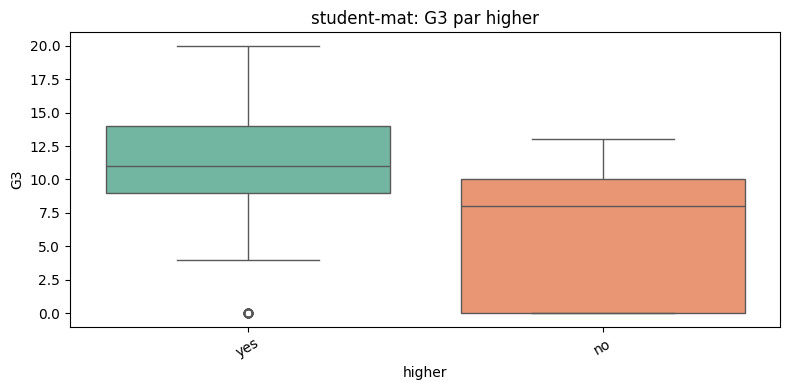

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


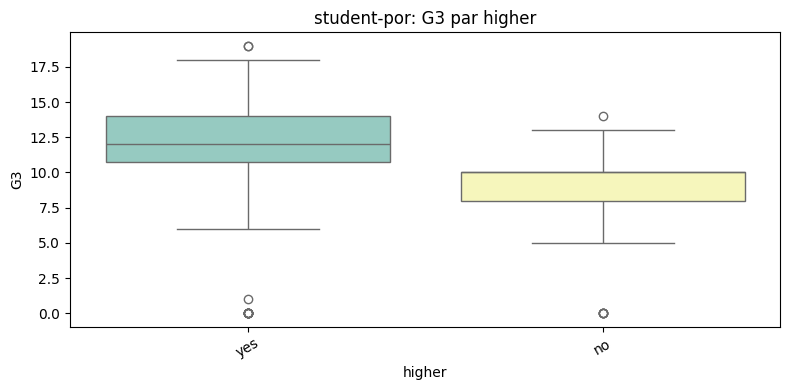

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


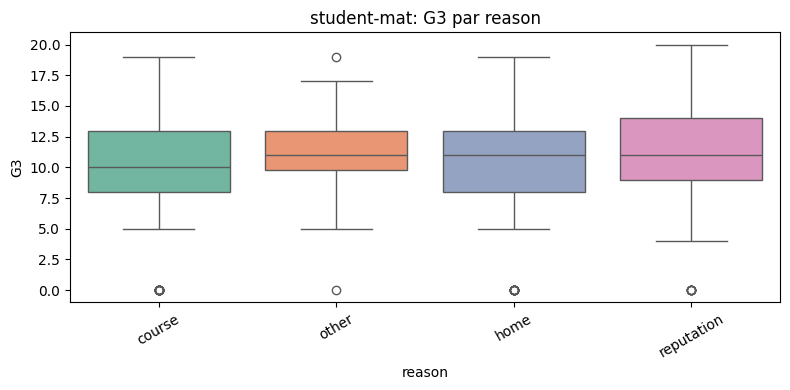

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


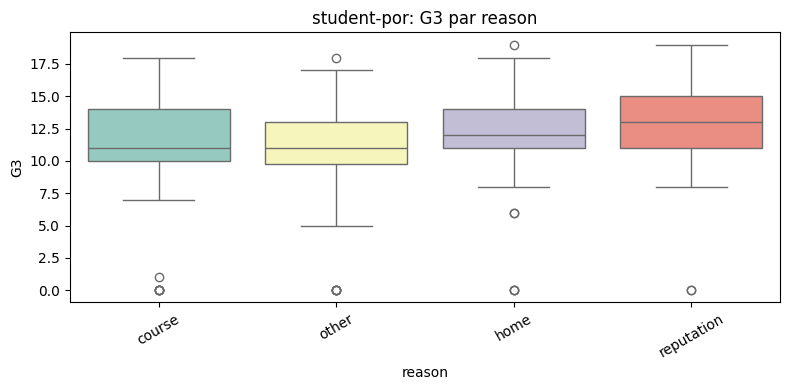

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


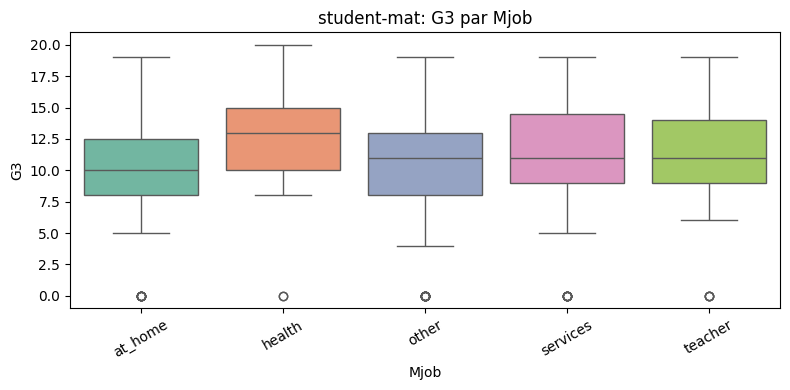

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


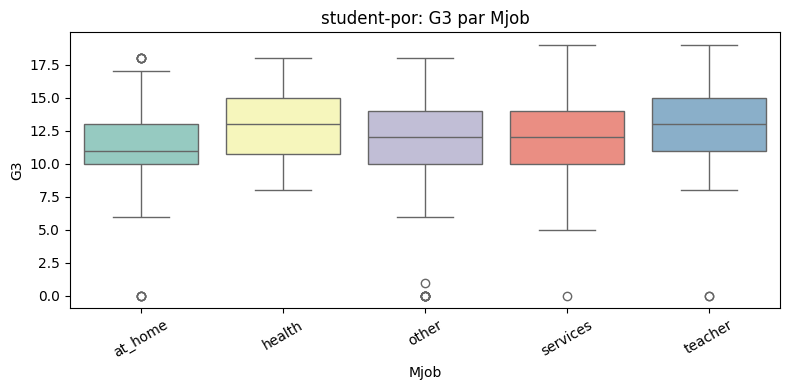

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


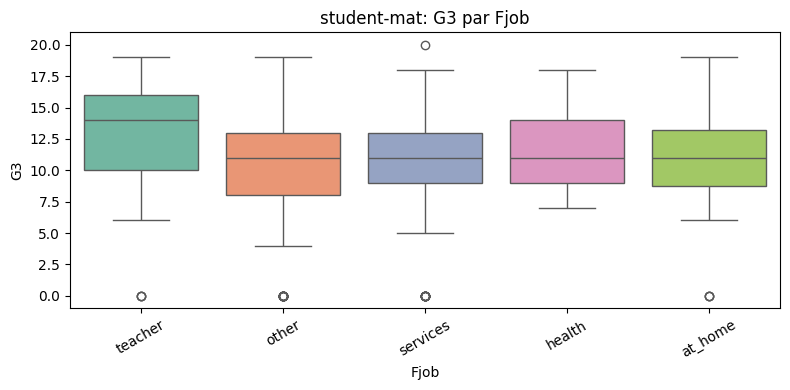

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


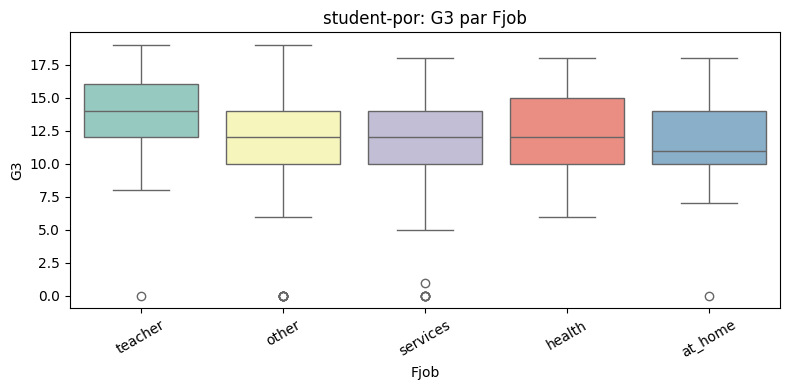

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


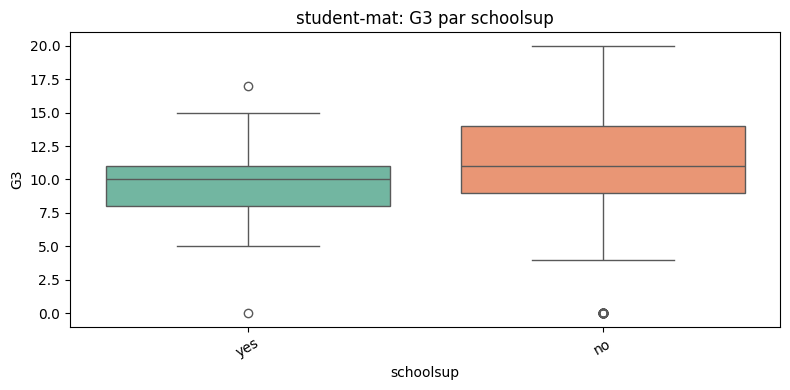

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


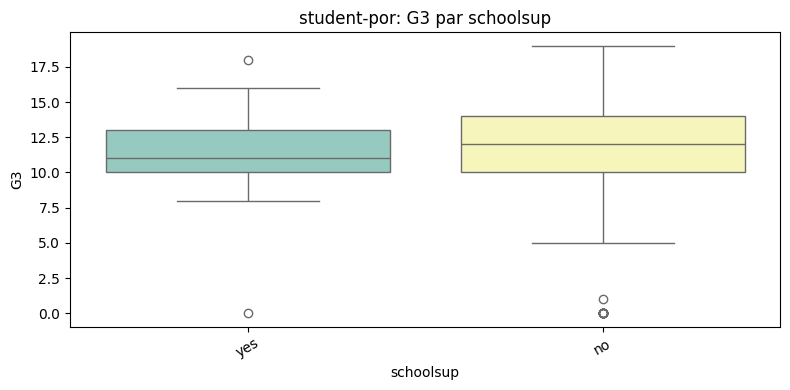

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


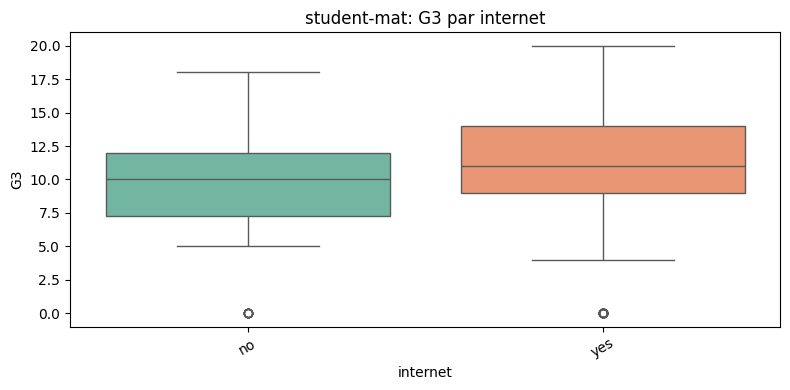

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


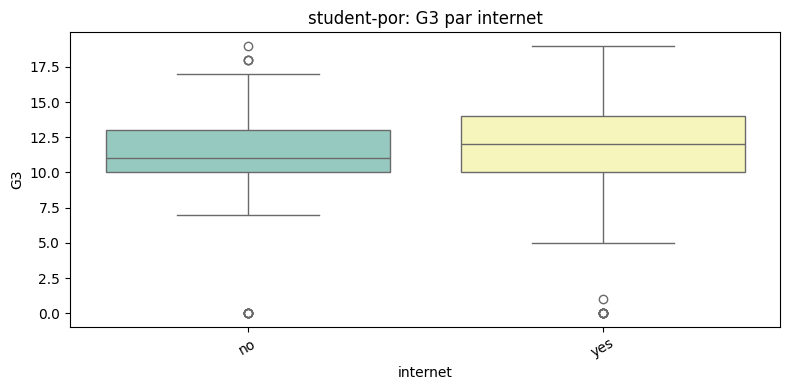

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


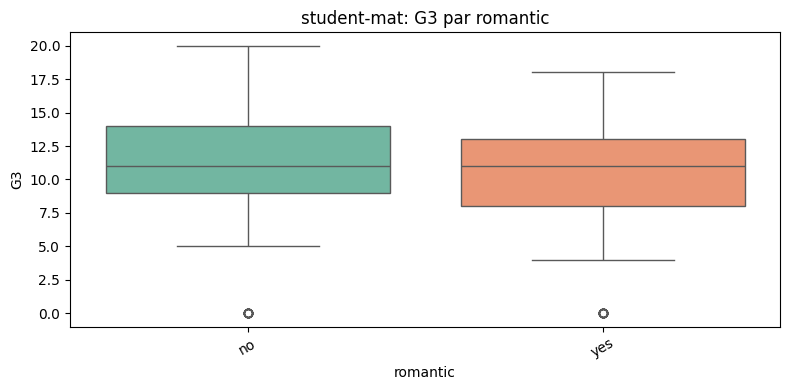

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


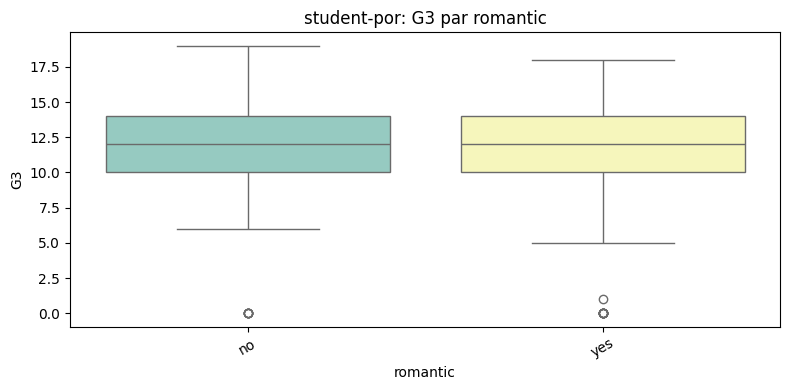

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


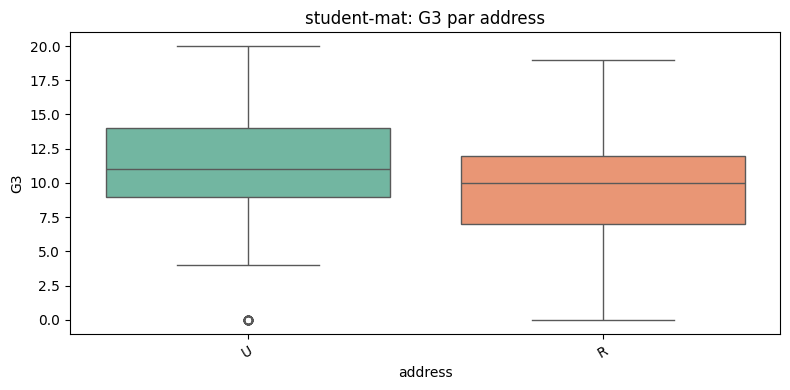

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


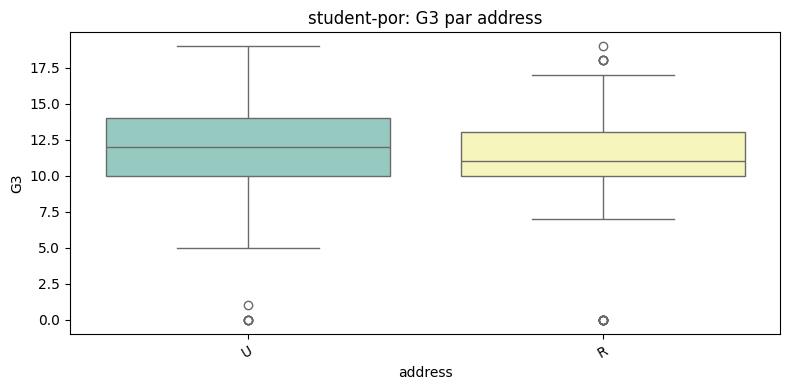

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


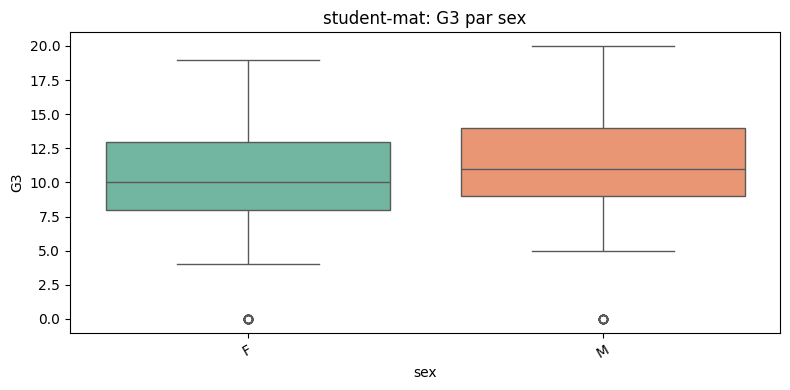

C:\Users\mathe\AppData\Local\Temp\ipykernel_4964\2635539141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')


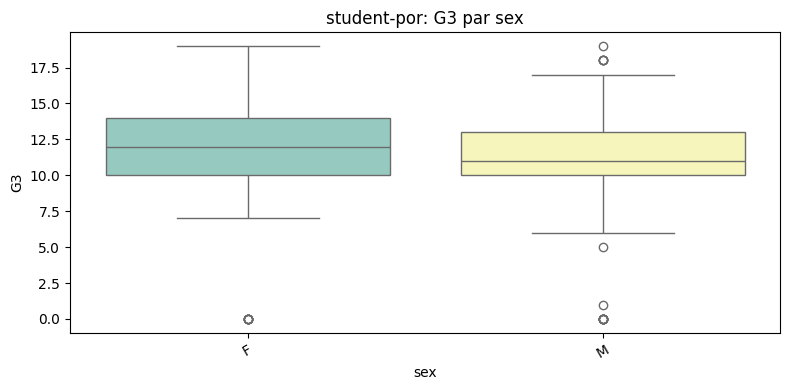

In [40]:
# Visualisations ciblées des facteurs catégoriels les plus impactants
top_cats = ['higher','reason','Mjob','Fjob','schoolsup','internet','romantic','address','sex']
for cat in top_cats:
    for name, df in [('student-mat', df_mat), ('student-por', df_por)]:
        plt.figure(figsize=(8,4))
        sns.boxplot(x=cat, y='G3', data=df, palette='Set2' if name == 'student-mat' else 'Set3')
        plt.title(f'{name}: G3 par {cat}')
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

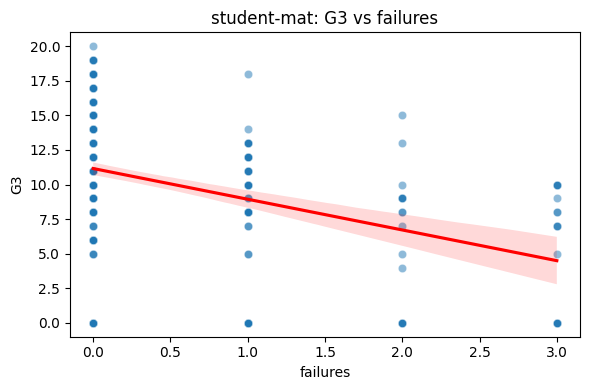

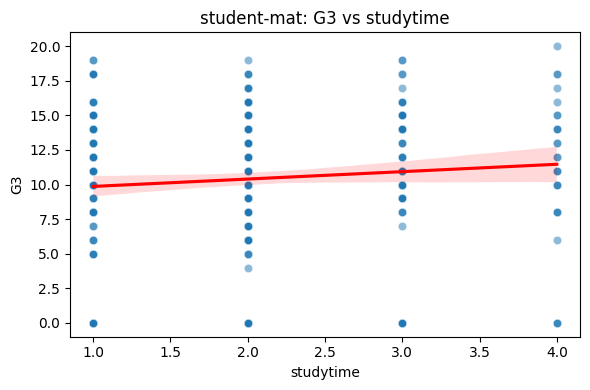

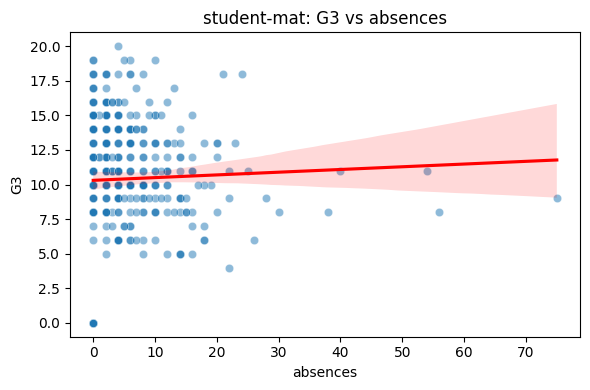

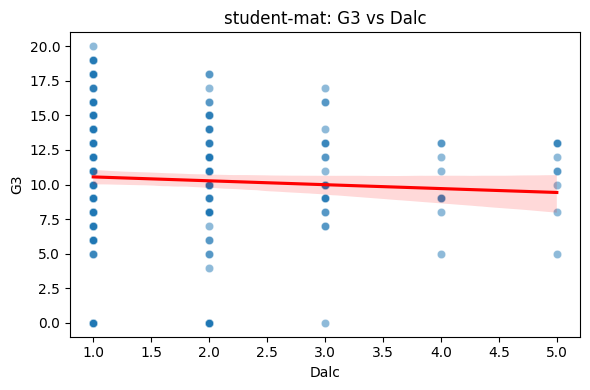

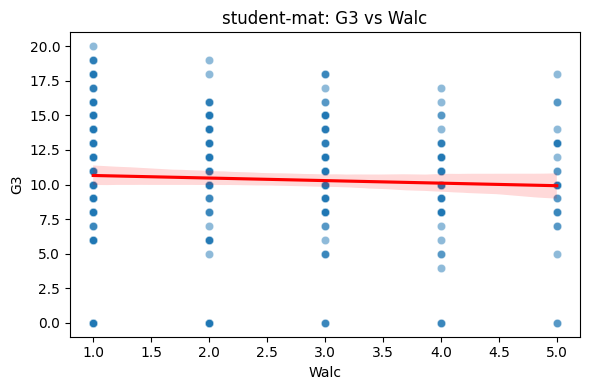

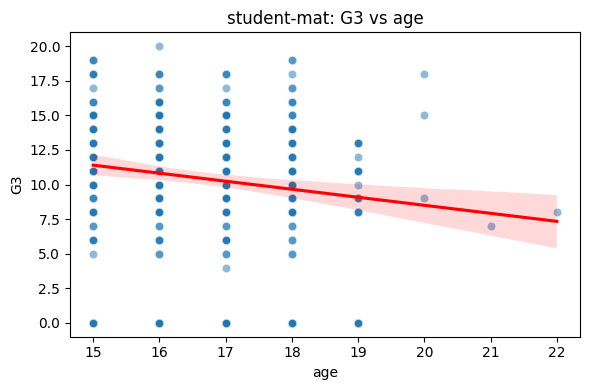

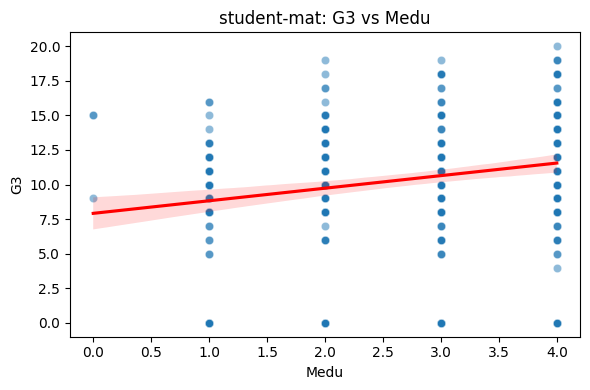

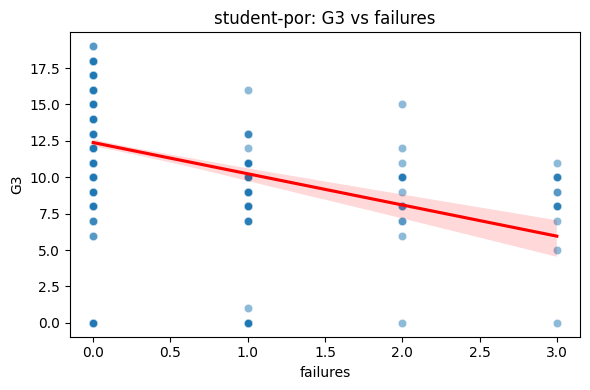

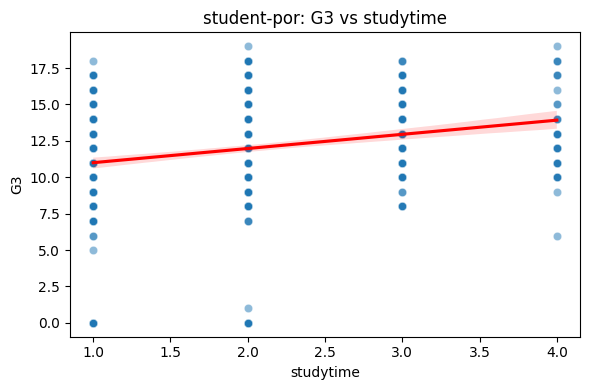

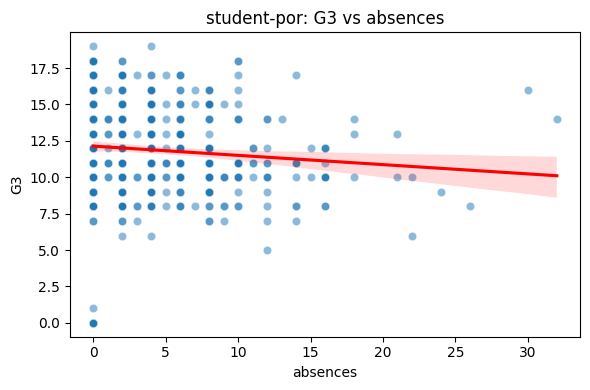

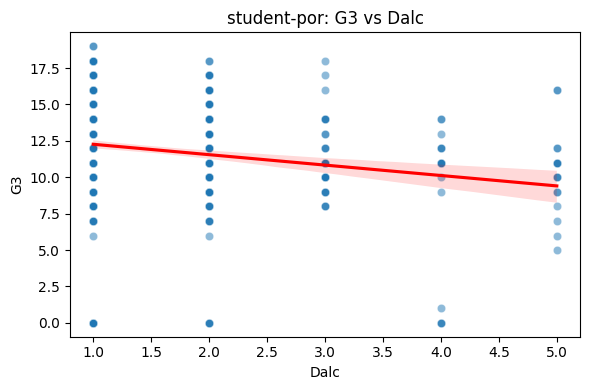

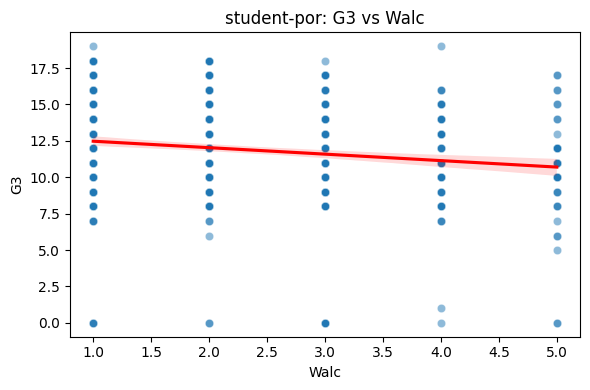

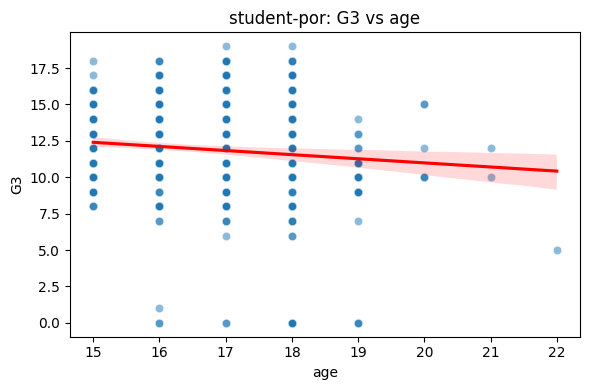

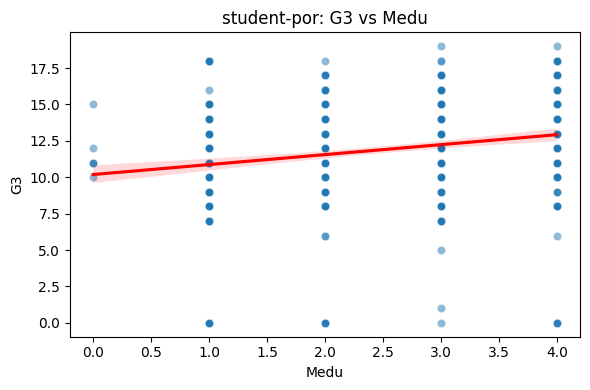

In [45]:
# Graphiques de corrélations faibles à modérées mais instructives
for name, df in [('student-mat', df_mat), ('student-por', df_por)]:
    for var in ['failures','studytime','absences','Dalc','Walc','age','Medu']:
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=var, y='G3', data=df, alpha=0.5)
        sns.regplot(x=var, y='G3', data=df, scatter=False, color='red')
        plt.title(f'{name}: G3 vs {var}')
        plt.tight_layout()
        plt.show()

## Interprétation visuelle
- `higher` est le facteur catégoriel le plus discriminant pour `G3` dans les deux jeux.
- `reason`, `Mjob`, et `Fjob` peuvent indiquer des différences de contexte familial ou professionnel liées aux résultats.
- `internet` et `romantic` montrent des effets de plus de 1 point sur la moyenne de `G3`, particulièrement sur `student-por`.
- Les variables de consommation (`Dalc`, `Walc`) et les `failures` sont des leviers intéressants, mais leur effet semble plus marqué dans `student-por`.

In [ ]:
# Statistiques descriptives pour les notes
for name, df in [('mat', df_mat), ('por', df_por)]:
    print(f'--- {name} ---')
    display(df[['G1','G2','G3']].describe())

--- mat ---


,G1,G2,G3
count,395.000000,395.000000,395.000000
mean,10.908861,10.713924,10.415190
std,3.319195,3.761505,4.581443
min,3.000000,0.000000,0.000000
25%,8.000000,9.000000,8.000000
50%,11.000000,11.000000,11.000000
75%,13.000000,13.000000,14.000000
max,19.000000,19.000000,20.000000


--- por ---


,G1,G2,G3
count,649.000000,649.000000,649.000000
mean,11.399076,11.570108,11.906009
std,2.745265,2.913639,3.230656
min,0.000000,0.000000,0.000000
25%,10.000000,10.000000,10.000000
50%,11.000000,11.000000,12.000000
75%,13.000000,13.000000,14.000000
max,19.000000,19.000000,19.000000


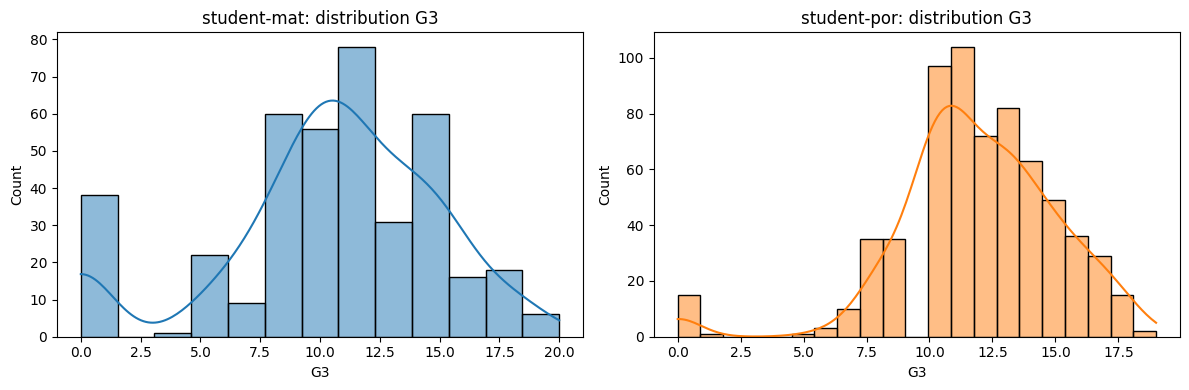

In [ ]:
# Distribution de G3 (notes finales) — histogramme + densité
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df_mat['G3'], kde=True, color='C0')
plt.title('student-mat: distribution G3')
plt.subplot(1,2,2)
sns.histplot(df_por['G3'], kde=True, color='C1')
plt.title('student-por: distribution G3')
plt.tight_layout()
plt.show()

Corrélation avec G3 (student-mat):


G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

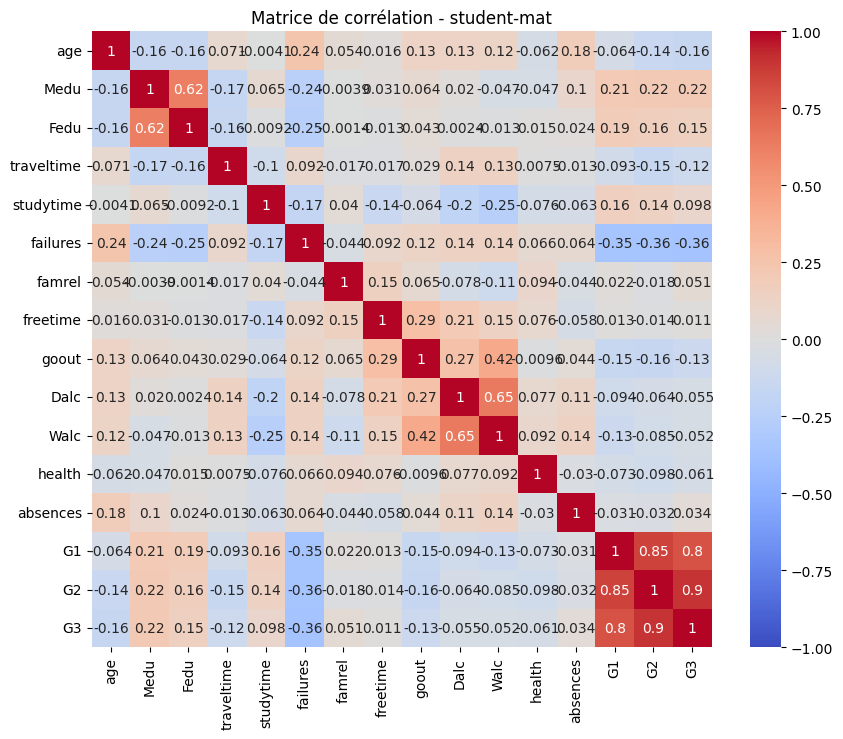

In [ ]:
# Corrélation simple entre variables numériques et G3 (mat)
num_cols = df_mat.select_dtypes(include=['int64','float64']).columns.tolist()
corr = df_mat[num_cols].corr()['G3'].sort_values(ascending=False)
print('Corrélation avec G3 (student-mat):')
display(corr)
# heatmap pour variables numériques (subset)
plt.figure(figsize=(10,8))
sns.heatmap(df_mat[num_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matrice de corrélation - student-mat')
plt.show()

## Premières pistes / prochaines étapes suggérées
Le projet attend un travail cohérent, des conclusions clairement expliquées et des éléments exploitables pour la soutenance orale.

Après ces premiers résultats, je recommande :
- Examiner les variables fortement corrélées avec `G3` et tester des modèles simples (régression linéaire).
- Comparer moyennes par catégories (`sex`, `higher`, `schoolsup`) avec boxplots et tests statistiques.
- Étudier l'impact des absences et de l'alcool (`Dalc`, `Walc`) sur l'évolution des notes (G1->G3).
- Fusionner les deux jeux si besoin pour analyses globales et construire des features (moyenne des notes, improvement flag).
- Si nécessaire, demander au nettoyeur de normaliser les noms/codes catégoriels pour faciliter les groupements.
- Préparer un support de rapport clair et synthétique : graphiques, conclusions et méthode (éviter le code brut dans le rapport).

Souhaitez-vous que j'exécute ces cellules et ajoute des visualisations supplémentaires (boxplots, tests, régressions rapides) ?